In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pickle

%load_ext autoreload
%autoreload 2

from data_helpers import prepare_this_data, torchify_this_data
from model_stuff import model_setup

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
df = pd.read_csv('../data/CESMDataset_Try.csv')
df

,AABW,NAO,SFWF,N_SALT,SALT_500m,ICEFRAC,PD_0m,PD_200m,TAUX,AMOC
0,-10.239799,-120.437500,-0.000012,-9.507178e+09,35.901257,0.650660,1.027776,1.028413,-0.041801,6.882782
1,-11.201758,-146.156250,-0.000011,-8.816568e+09,35.901064,0.648288,1.027779,1.028421,-0.040765,6.435627
2,-12.287320,0.796875,-0.000010,-9.958823e+09,35.901559,0.646489,1.027737,1.028430,-0.048542,5.820034
3,-8.847480,-18.187500,-0.000010,-6.875848e+09,35.900959,0.654712,1.027721,1.028435,-0.040110,6.062874
4,-10.571012,-46.929688,-0.000012,-8.184854e+09,35.901122,0.656720,1.027708,1.028434,-0.043197,5.727042
...,...,...,...,...,...,...,...,...,...,...
15791,-7.111198,543.718750,0.000020,-6.890116e+09,35.798163,0.338218,1.028218,1.028687,-0.042785,15.874332
15792,-9.695823,210.445312,0.000009,-7.132759e+09,35.801350,0.389467,1.028286,1.028681,-0.063885,16.431360
15793,-8.272045,801.992188,0.000016,-9.324583e+09,35.804327,0.365907,1.028220,1.028674,-0.056238,16.284046
15794,-7.331819,-95.929688,0.000021,-1.022291e+10,35.804732,0.364335,1.028188,1.028681,-0.041210,15.983460


Epoch 0 with train loss: 0.2606759070483751 and eval loss: 0.17412943858653307
Epoch 1 with train loss: 0.07703921376445959 and eval loss: 0.10084970605870087
Epoch 2 with train loss: 0.06195078482634799 and eval loss: 0.10441997336844604
Epoch 3 with train loss: 0.05820240587169348 and eval loss: 0.1000949718678991
Epoch 4 with train loss: 0.05562332554092241 and eval loss: 0.08284949076672395
Epoch 5 with train loss: 0.0536773310930923 and eval loss: 0.07265165199836095
Epoch 6 with train loss: 0.05305437817303247 and eval loss: 0.06583883939310908
Epoch 7 with train loss: 0.05164948898519194 and eval loss: 0.06326329878841837
Epoch 8 with train loss: 0.050668109511566715 and eval loss: 0.06280526239424944
Epoch 9 with train loss: 0.050570446608024976 and eval loss: 0.06539869479214151
Epoch 10 with train loss: 0.049537135288119316 and eval loss: 0.06165378742540876
Epoch 11 with train loss: 0.04886719129633072 and eval loss: 0.053452025167644024
Epoch 12 with train loss: 0.049444908

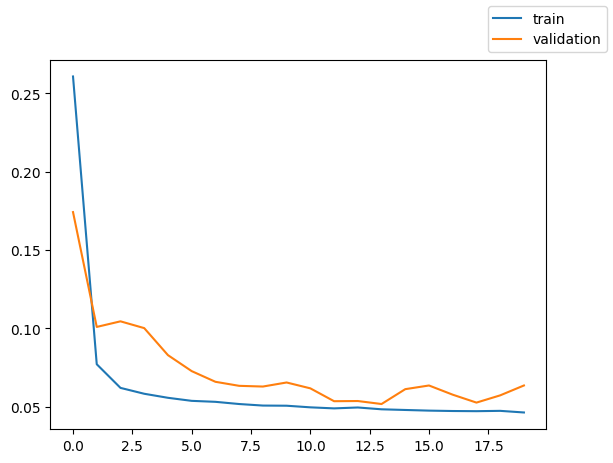

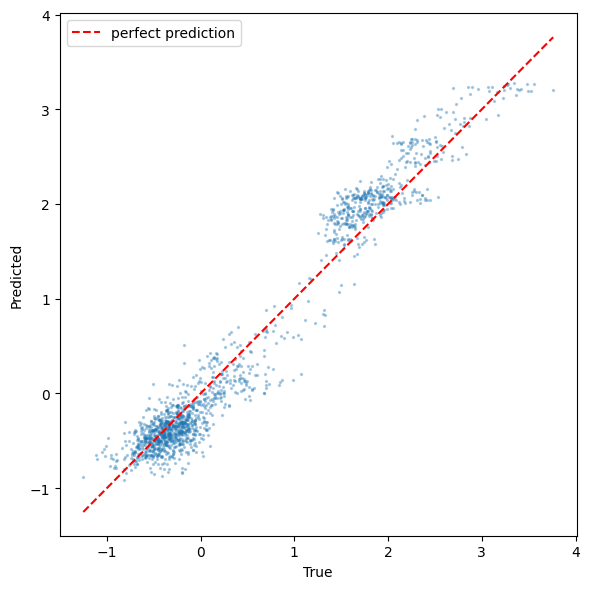

In [24]:
''' 
Data processing
'''

target_col = 'AMOC'
feature_cols = ['SFWF', 'PD_200m']
lag = 50
horizon = 1
n = len(df)
train_end = int(n * 0.7)
test_end = int(n * 0.9)
batch_size = 128

X_train_lag, y_train_lag, X_test_lag, y_test_lag, X_eval_lag, y_eval_lag, y_scaler, x_scaler = prepare_this_data(df, 
                                                                                                                 target_col, 
                                                                                                                 feature_cols,
                                                                                                                 train_end,
                                                                                                                 test_end,
                                                                                                                 lag,
                                                                                                                 horizon)

X_train_t, y_train_t, train_loader, X_test_t, y_test_t, test_loader, X_eval_t, y_eval_t, eval_loader = torchify_this_data(batch_size, 
                                                                                                                          X_train_lag, 
                                                                                                                          y_train_lag, 
                                                                                                                          X_test_lag, 
                                                                                                                          y_test_lag, 
                                                                                                                          X_eval_lag, 
                                                                                                                          y_eval_lag)
device = "cpu"
n_epochs = 20

params = {
    'n_features': len(feature_cols),
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'lr': 1e-3,
    'loss_fn': nn.MSELoss()
}

NN_AMOC, train_losses, eval_losses = model_setup(device, params, n_epochs, train_loader, eval_loader, X_eval_t, y_eval_lag)

torch.save({
    'state_dict': NN_AMOC.state_dict(),
    'config': {
        'n_features': len(feature_cols),
        'hidden_size': 64,
        'num_layers': 1,
        'dropout': 0.0,
    },
}, 'amoc_model.pth')

with open('scalers_AMOC.pkl', 'wb') as f:
    pickle.dump({'y_scaler': y_scaler, 'x_scaler': x_scaler}, f)

